# 01 — Data Exploration
Thin view over the artifacts produced by `scripts/run_eda.py`.
Re-run that script to refresh the underlying tables and figures.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))
import pandas as pd
from IPython.display import Image, display
from src import config


## Scope summary

In [2]:
summary = json.loads((config.TABLES / 'eda' / 'summary.json').read_text())
summary


{'rows': 28254,
 'priority_counts': {'low': 5774, 'medium': 11565, 'high': 10915},
 'department_counts': {'Technical Support': 8147,
  'Product Support': 5301,
  'Customer Service': 4269,
  'IT Support': 3333,
  'Billing and Payments': 2896,
  'Returns and Exchanges': 1402,
  'Service Outages and Maintenance': 1106,
  'Sales and Pre-Sales': 843,
  'Human Resources': 553,
  'General Inquiry': 404},
 'mean_ticket_tokens': 60.473773624973454,
 'mean_answer_tokens': 58.38652934097827,
 'median_ticket_tokens': 59.0,
 'median_answer_tokens': 59.0}

## Class distributions

In [3]:
pd.read_csv(config.TABLES / 'eda' / 'priority_counts.csv')


,priority,count
0,low,5774
1,medium,11565
2,high,10915


In [4]:
pd.read_csv(config.TABLES / 'eda' / 'department_counts.csv')


,department,count
0,Technical Support,8147
1,Product Support,5301
2,Customer Service,4269
3,IT Support,3333
4,Billing and Payments,2896
5,Returns and Exchanges,1402
6,Service Outages and Maintenance,1106
7,Sales and Pre-Sales,843
8,Human Resources,553
9,General Inquiry,404


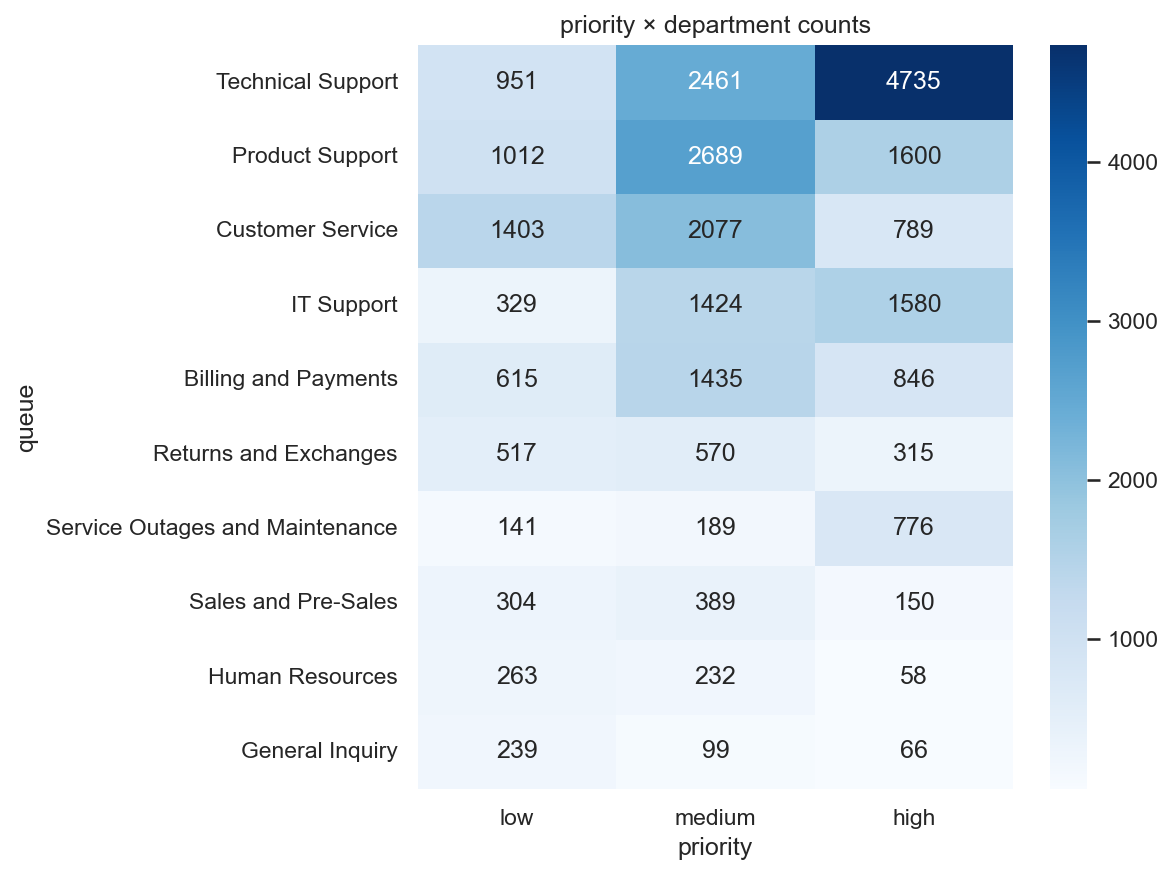

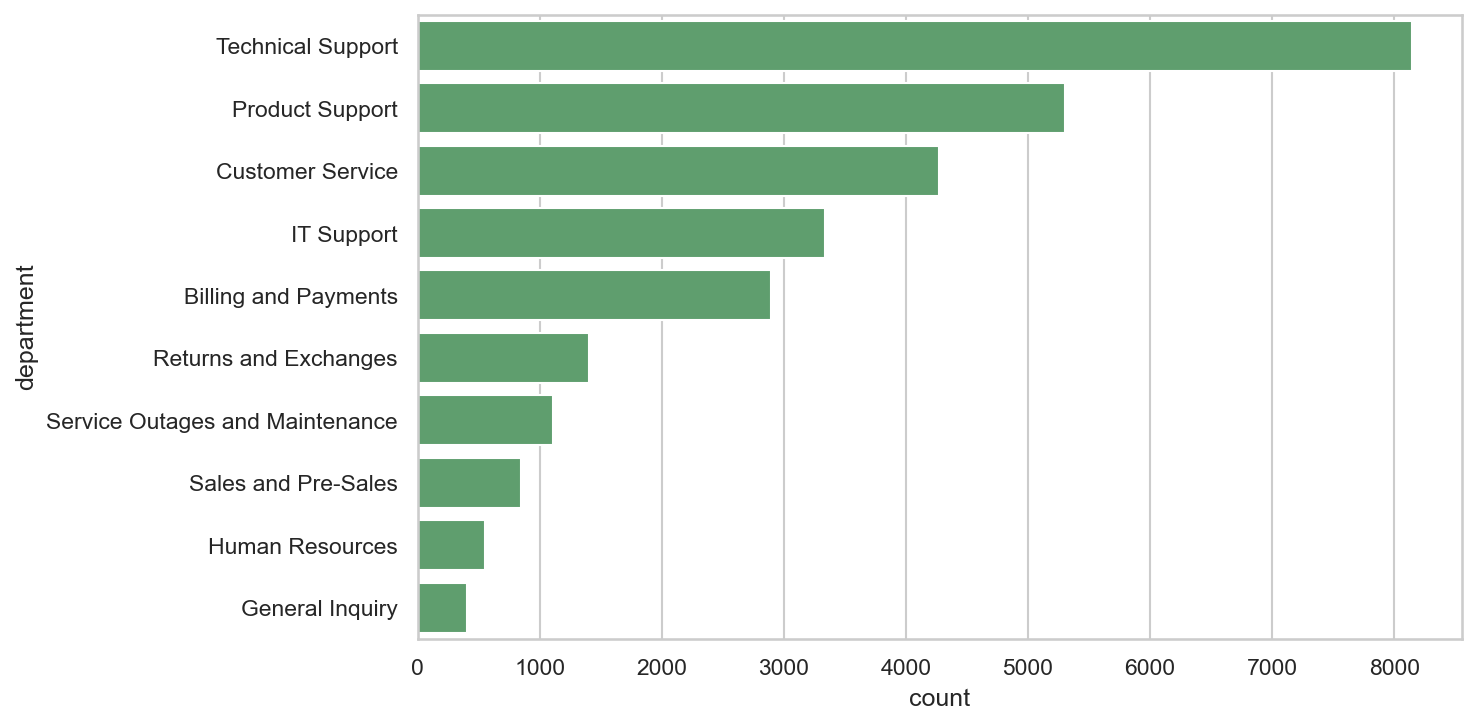

In [5]:
display(Image(filename=str(config.FIGURES / 'eda' / 'priority_department_heatmap.png')))
display(Image(filename=str(config.FIGURES / 'eda' / 'department_counts.png')))


## Length distributions

In [6]:
pd.read_csv(config.TABLES / 'eda' / 'length_by_priority.csv', header=[0,1], index_col=0)


ticket_tokens               answer_tokens               ticket_chars  \
                  mean median    std          mean median    std         mean   
priority                                                                        
high             60.01   59.0  30.77         58.70   60.0  28.04       407.96   
low              60.67   59.0  31.81         58.08   58.0  28.35       409.71   
medium           60.81   60.0  32.04         58.24   59.0  28.61       411.76   

                        answer_chars                 
         median     std         mean median     std  
priority                                             
high      405.0  198.49       373.88  374.0  175.95  
low       400.0  205.02       370.65  364.0  177.49  
medium    405.0  206.21       372.30  373.0  180.65

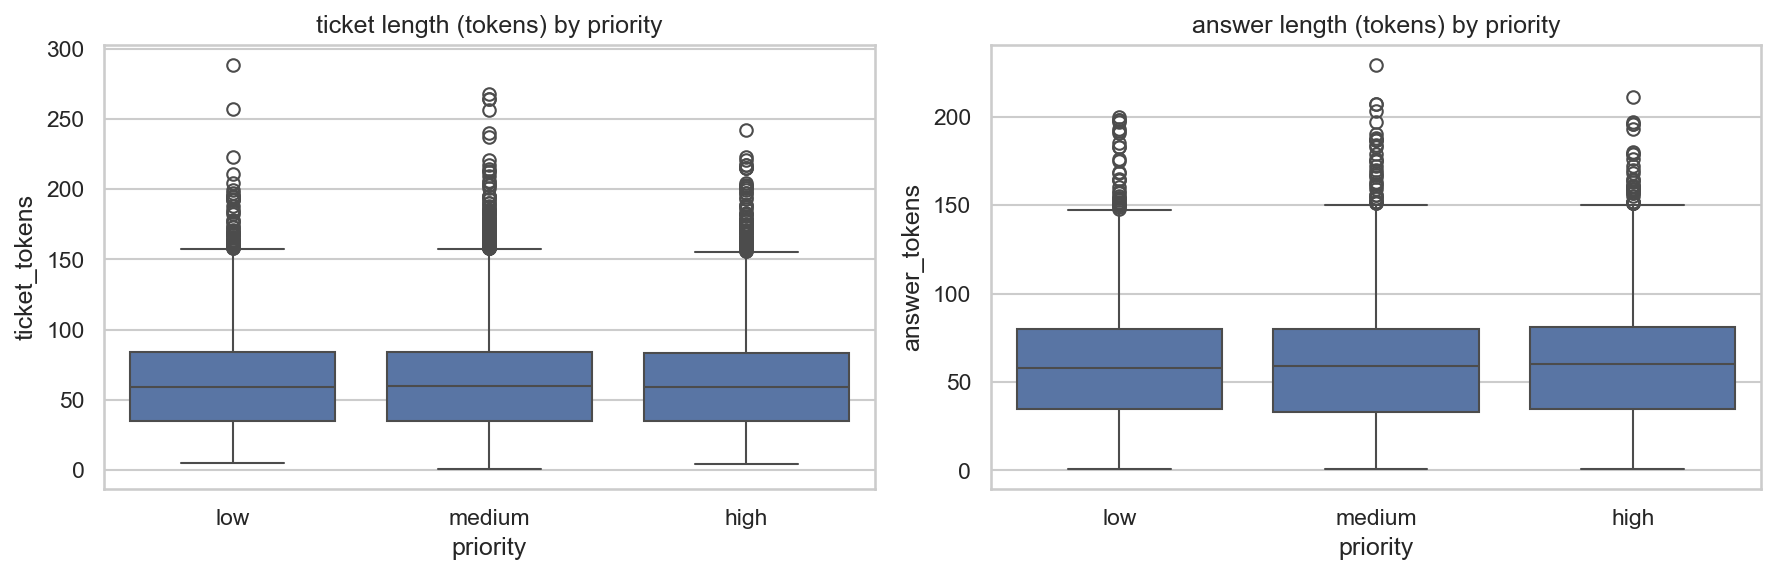

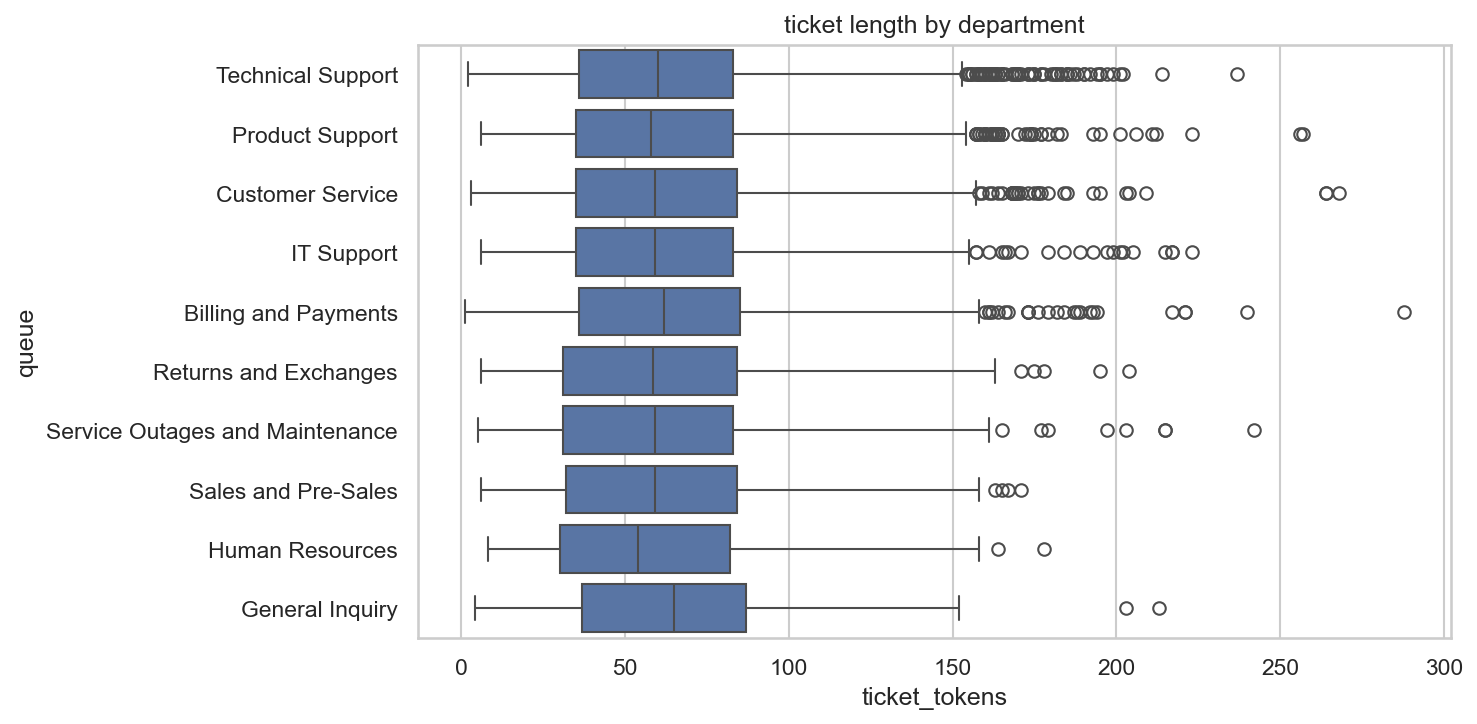

In [7]:
display(Image(filename=str(config.FIGURES / 'eda' / 'length_by_priority.png')))
display(Image(filename=str(config.FIGURES / 'eda' / 'ticket_length_by_department.png')))


## Top n-grams per priority

In [8]:
pd.read_csv(config.TABLES / 'eda' / 'top_ngrams_by_priority.csv').groupby('priority').head(10)


,priority,ngram,count
0,low,data,5076
1,low,support,3088
2,low,issue,2922
3,low,assistance,2243
4,low,information,2198
5,low,customer,2125
6,low,provide,2041
7,low,software,1957
8,low,security,1941
9,low,problem,1934


## TF-IDF → SVD(2) projection

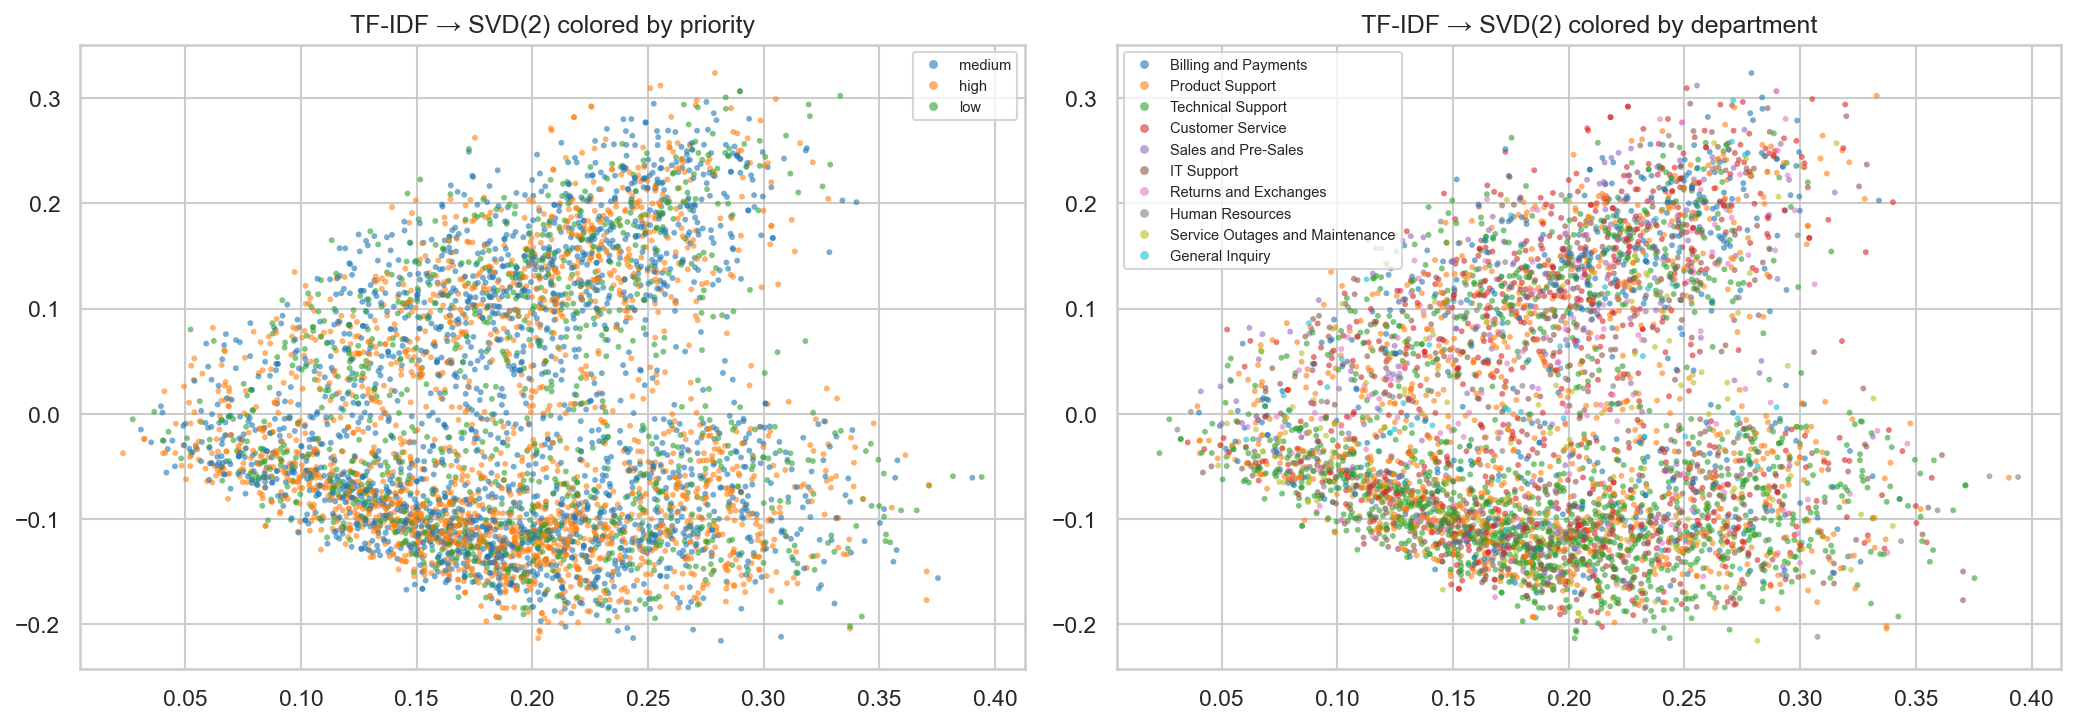

In [9]:
display(Image(filename=str(config.FIGURES / 'eda' / 'tfidf_svd_scatter.png')))
